<a href="https://colab.research.google.com/github/StillGrowing-25/Applied-Machine-Learning/blob/main/Stock%20Price%20Prediction/Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#loading dataset and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

# SAME DATASET
df = pd.read_csv('Tesla Dataset.csv')

Feature Engineering

In [4]:
splitted = df['Date'].str.split('/', expand=True)

df['Date'] = pd.to_datetime(df['Date'])

df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

df['is_quarter_end'] = np.where(df['month'] % 3 == 0, 1, 0)

df['open-close'] = df['Open'] - df['Close']
df['low-high'] = df['Low'] - df['High']

Time series addition

In [5]:
# Sort by date (IMPORTANT for time series)
df = df.sort_values(by=['year', 'month', 'day'])

# Create lag features (previous values)
df['lag_1'] = df['Close'].shift(1)
df['lag_2'] = df['Close'].shift(2)
df['lag_3'] = df['Close'].shift(3)

# New target: FUTURE PRICE (regression)
df['target'] = df['Close'].shift(-1)

# Drop NaN values
df = df.dropna()

Features and target

In [6]:
features = df[['open-close', 'low-high', 'is_quarter_end', 'lag_1', 'lag_2', 'lag_3']]
target = df['target']

# Scaling
scaler = StandardScaler()
features = scaler.fit_transform(features)

Split


In [7]:
train_size = int(len(features) * 0.8)

X_train = features[:train_size]
X_test = features[train_size:]

y_train = target[:train_size]
y_test = target[train_size:]

Prediction

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
preds = model.predict(X_test)

Evaluation

In [9]:
print("MAE:", metrics.mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, preds)))

MAE: 7.6953338629063355
RMSE: 10.679396688584589


Plot Results

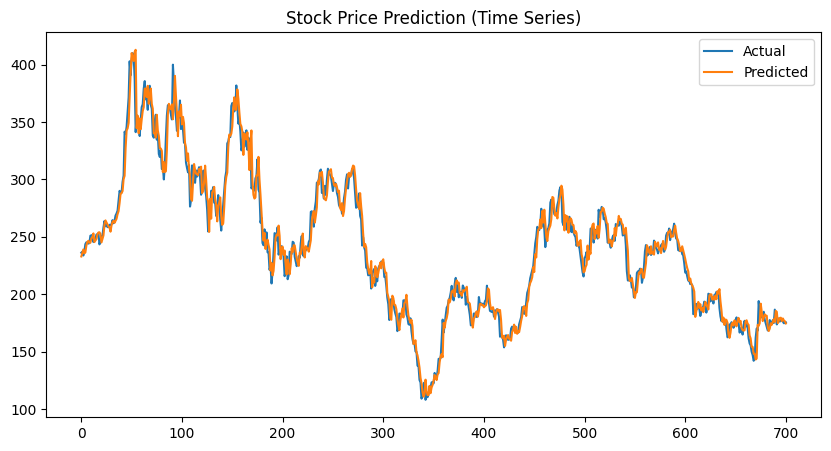

In [10]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title("Stock Price Prediction (Time Series)")
plt.show()